In [1]:
!pip install scikit-learn pandas numpy joblib -q

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [3]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(df.shape)

print(df["Churn"].value_counts())

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [7]:
df.drop(
    columns=["customerID"],
    inplace=True
)

In [8]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [9]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print(numerical_features)
print(categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [12]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [13]:
categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [15]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

In [17]:
logistic_params = {
    "classifier__C":[0.01,0.1,1,10],
    "classifier__penalty":["l2"]
}
logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

logistic_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l2']},
             scoring='f1')

In [18]:
print(
    logistic_grid.best_params_
)

print(
    logistic_grid.best_score_
)

{'classifier__C': 10, 'classifier__penalty': 'l2'}
0.598413168551094


In [19]:
best_logistic = logistic_grid.best_estimator_

preds = best_logistic.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,preds)
)

print(
    "F1 Score:",
    f1_score(y_test,preds)
)

print(
    classification_report(
        y_test,
        preds
    )
)

Accuracy: 0.8055358410220014
F1 Score: 0.6040462427745664
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [20]:
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [21]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,None],
    "classifier__min_samples_split":[2,5]
}
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='f1')

In [22]:
print(
    rf_grid.best_params_
)

print(
    rf_grid.best_score_
)

{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
0.5715213018938158


In [23]:
best_rf = rf_grid.best_estimator_

rf_preds = best_rf.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_preds
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        rf_preds
    )
)

print(
    classification_report(
        y_test,
        rf_preds
    )
)

Accuracy: 0.7998580553584103
F1 Score: 0.5778443113772455
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [24]:
log_acc = accuracy_score(
    y_test,
    preds
)

rf_acc = accuracy_score(
    y_test,
    rf_preds
)

print("Logistic:", log_acc)
print("Random Forest:", rf_acc)

Logistic: 0.8055358410220014
Random Forest: 0.7998580553584103


In [25]:
joblib.dump(
    best_logistic,
    "telco_churn_pipeline.pkl"
)

['telco_churn_pipeline.pkl']

In [26]:
loaded_model = joblib.load(
    "telco_churn_pipeline.pkl"
)

In [27]:
new_customer = pd.DataFrame({
    "gender":["Female"],
    "SeniorCitizen":[0],
    "Partner":["Yes"],
    "Dependents":["No"],
    "tenure":[12],
    "PhoneService":["Yes"],
    "MultipleLines":["No"],
    "InternetService":["Fiber optic"],
    "OnlineSecurity":["No"],
    "OnlineBackup":["Yes"],
    "DeviceProtection":["No"],
    "TechSupport":["No"],
    "StreamingTV":["Yes"],
    "StreamingMovies":["Yes"],
    "Contract":["Month-to-month"],
    "PaperlessBilling":["Yes"],
    "PaymentMethod":["Electronic check"],
    "MonthlyCharges":[80],
    "TotalCharges":[960]
})

In [28]:
prediction = loaded_model.predict(
    new_customer
)

print(
    "Churn"
    if prediction[0]==1
    else "No Churn"
)

Churn


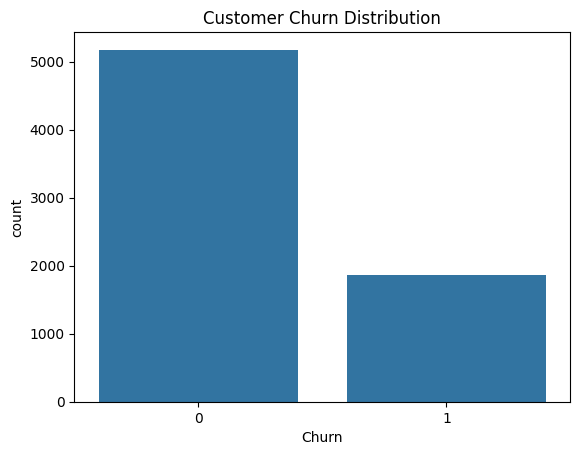

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

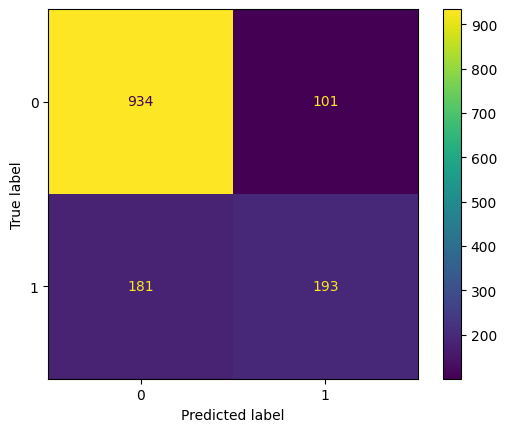

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.show()